# Лабораторная 4. SVM для определения P300

**Что делаем:** учим SVM отличать в ЭЭГ-эпохе наличие P300 (целевой стимул) от его отсутствия.

**Шаги:**
1. Загрузить данные через moabb
2. Сделать признаки
3. Реализовать SVM с нуля
4. Посчитать метрики + ROC

## 0. Датасет

Взял **BNCI2014-009** через moabb. По ТЗ референс на bi2013a (7.5 ГБ, качать долго), но парадигма та же — P300-спеллер. Этот датасет — 18 МБ на испытуемого, 16 каналов, 256 Гц.

Беру 3 испытуемых (1, 2, 3) → 5184 эпохи.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import moabb.datasets as mds
import moabb.paradigms as mpdg

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. Загрузка

Параметры парадигмы P300:
- `fmin=1, fmax=20` — фильтр (P300 медленный, выше 20 Гц шум)
- `tmin=0, tmax=0.8` — эпоха после стимула (P300 в 250-500 мс)
- `resample=128` — частота с 256 на 128 Гц, признаков в 2 раза меньше

In [2]:
paradigm = mpdg.P300(fmin=1, fmax=20, tmin=0.0, tmax=0.8, resample=128.0)
dataset = mds.BNCI2014_009()

t0 = time.time()
X, y_str, meta = paradigm.get_data(dataset=dataset, subjects=[1, 2, 3])
print(f'Загрузка: {time.time()-t0:.1f} с')
print(f'X shape: {X.shape}   (эпох × каналов × отсчётов)')
print(f'Классы:  {dict(zip(*np.unique(y_str, return_counts=True)))}')

Загрузка: 2.5 с
X shape: (5184, 16, 103)   (эпох × каналов × отсчётов)
Классы:  {np.str_('NonTarget'): np.int64(4320), np.str_('Target'): np.int64(864)}


In [3]:
y = np.where(y_str == 'Target', 1, -1)
n_pos = (y == 1).sum()
n_neg = (y == -1).sum()
print(f'Target (+1):    {n_pos}')
print(f'NonTarget (-1): {n_neg}')
print(f'Отношение: 1 к {n_neg/n_pos:.1f}')

Target (+1):    864
NonTarget (-1): 4320
Отношение: 1 к 5.0


## 2. Смотрим P300 на средних эпохах

Одна эпоха — шум. Усреднили много — должен проявиться характерный горб у Target в 300-500 мс.

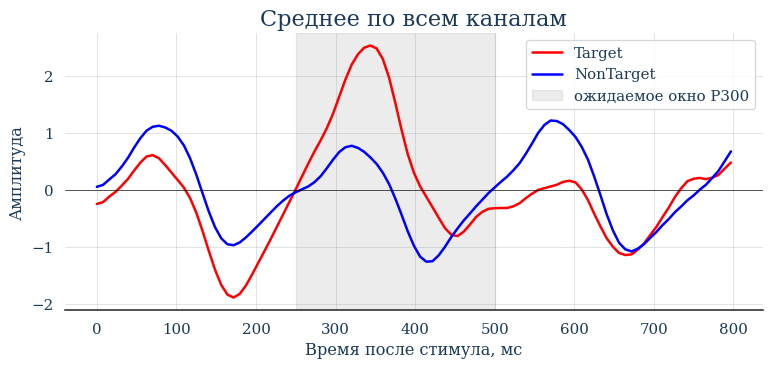

In [4]:
fs = 128.0
times = np.arange(X.shape[2]) / fs * 1000

mean_target = X[y == 1].mean(axis=0)
mean_nontarget = X[y == -1].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, mean_target.mean(axis=0),    label='Target',    color='red',  lw=2)
ax.plot(times, mean_nontarget.mean(axis=0), label='NonTarget', color='blue', lw=2)
ax.axvspan(250, 500, alpha=0.15, color='gray', label='ожидаемое окно P300')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Время после стимула, мс')
ax.set_ylabel('Амплитуда')
ax.set_title('Среднее по всем каналам')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

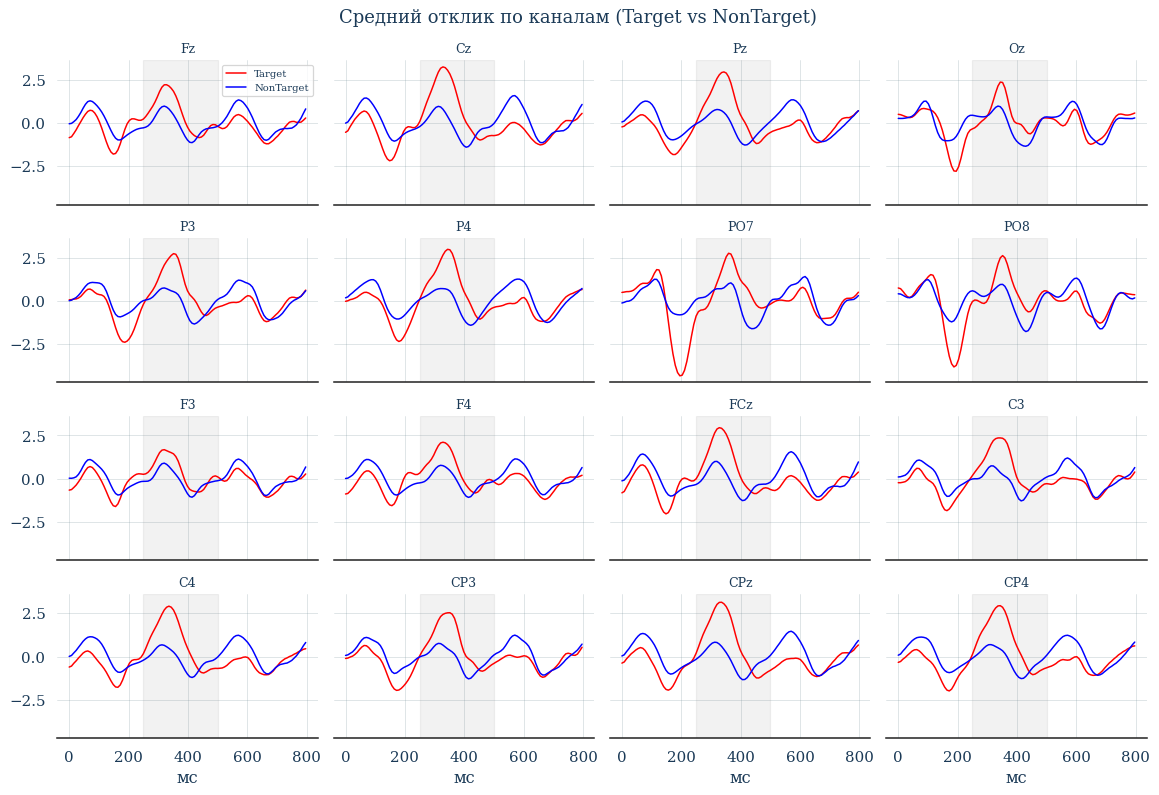

In [5]:
ch_names = ['Fz','Cz','Pz','Oz','P3','P4','PO7','PO8',
            'F3','F4','FCz','C3','C4','CP3','CPz','CP4']

fig, axes = plt.subplots(4, 4, figsize=(13, 9), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    ax.plot(times, mean_target[i],    color='red',  lw=1.2, label='Target')
    ax.plot(times, mean_nontarget[i], color='blue', lw=1.2, label='NonTarget')
    ax.axvspan(250, 500, alpha=0.1, color='gray')
    ax.set_title(ch_names[i], fontsize=10)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel('мс')
fig.suptitle('Средний отклик по каналам (Target vs NonTarget)')
plt.tight_layout()
plt.show()

На картинках видно: у Target горб 300-500 мс есть, у NonTarget около нуля. Особенно явно в Pz, Cz, CPz. В одной эпохе тонет в шуме — нужен классификатор.

## 3. Признаки

Эпоха = 16 каналов × 103 отсчёта = 1648 чисел. Подавать всё в SVM — много, переобучимся.

Беру **среднее в 6 временных окнах** для каждого канала → $16 \cdot 6 = 96$ признаков. Шесть окон — компромисс между формой волны и шумом.

Потом z-нормализация $x'_j = (x_j - \mu_j) / \sigma_j$ — иначе признак с большим разбросом перетянет на себя $\|w\|$.

In [6]:
def extract_features(X, n_windows=6):
    n_t = X.shape[2]
    win_size = n_t // n_windows
    parts = []
    for i in range(n_windows):
        start = i * win_size
        end = start + win_size
        parts.append(X[:, :, start:end].mean(axis=2))
    return np.concatenate(parts, axis=1)


F = extract_features(X, n_windows=6)
print('Размер матрицы признаков:', F.shape)

Размер матрицы признаков: (5184, 96)


In [7]:
def train_test_split(y, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    pos = np.where(y == 1)[0]
    neg = np.where(y == -1)[0]
    rng.shuffle(pos)
    rng.shuffle(neg)
    n_pos_test = int(len(pos) * test_size)
    n_neg_test = int(len(neg) * test_size)
    test  = np.concatenate([pos[:n_pos_test], neg[:n_neg_test]])
    train = np.concatenate([pos[n_pos_test:], neg[n_neg_test:]])
    rng.shuffle(train)
    rng.shuffle(test)
    return train, test


train_idx, test_idx = train_test_split(y, test_size=0.2)
F_tr, y_tr = F[train_idx], y[train_idx]
F_te, y_te = F[test_idx],  y[test_idx]

mu = F_tr.mean(axis=0)
sd = F_tr.std(axis=0) + 1e-9
F_tr = (F_tr - mu) / sd
F_te = (F_te - mu) / sd

print(f'train: {F_tr.shape},  +1/-1: {(y_tr==1).sum()}/{(y_tr==-1).sum()}')
print(f'test:  {F_te.shape},  +1/-1: {(y_te==1).sum()}/{(y_te==-1).sum()}')

train: (4148, 96),  +1/-1: 692/3456
test:  (1036, 96),  +1/-1: 172/864


## 4. SVM

Граница $w \cdot x + b = 0$, ищем максимальный зазор. Soft-margin: разрешаем нарушения, штрафуем через hinge.

$$L(w, b) = \frac{\|w\|^2}{2C} + \frac{1}{n}\sum_{i=1}^{n} \max\!\left(0,\ 1 - y_i(w \cdot x_i + b)\right)$$

Первое слагаемое — L2-регуляризация, второе — средний hinge loss.

Метки $y \in \{-1, +1\}$, чтобы $y_i (w \cdot x_i + b) > 0$ означало правильный ответ.

Ядро линейное: при 96 признаках линейная модель уже гибкая, RBF потребовал бы матрицу $N \times N$.

Учим обычным градиентным спуском.

In [8]:
class LinearSVM:
    def __init__(self, C=1.0, lr=0.01, n_epochs=200):
        self.C = C
        self.lr = lr
        self.n_epochs = n_epochs

    def fit(self, X, y, sample_weight=None):
        n, d = X.shape
        if sample_weight is None:
            sample_weight = np.ones(n)

        self.w = np.zeros(d)
        self.b = 0.0
        self.losses = []

        for epoch in range(self.n_epochs):
            margin = y * (X @ self.w + self.b)
            active = margin < 1

            grad_w_hinge = -(sample_weight[active] * y[active]) @ X[active] / n
            grad_b_hinge = -(sample_weight[active] * y[active]).sum() / n

            grad_w = self.w / self.C + grad_w_hinge
            grad_b = grad_b_hinge

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            hinge = np.maximum(0, 1 - margin) * sample_weight
            loss = 0.5 * (self.w @ self.w) / self.C + hinge.mean()
            self.losses.append(loss)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

**Дисбаланс 1:5** — без поправки SVM игнорирует Target. Веса классов: $w_{+} = \frac{N}{2 N_{+}}$, $w_{-} = \frac{N}{2 N_{-}}$ — суммарный вес каждого класса становится одинаковый.

In [9]:
def class_weights(y):
    n = len(y)
    n_pos = (y == 1).sum()
    n_neg = (y == -1).sum()
    w_pos = n / (2 * n_pos)
    w_neg = n / (2 * n_neg)
    return np.where(y == 1, w_pos, w_neg)

## 5. Подбор C

3-фолдовая CV на train. Метрика — F1 (accuracy при дисбалансе 1:5 даёт baseline 0.83 даже на тривиальном «всегда NonTarget»).

In [10]:
def f1_score(y_true, y_pred):
    tp = ((y_pred == 1)  & (y_true == 1)).sum()
    fp = ((y_pred == 1)  & (y_true == -1)).sum()
    fn = ((y_pred == -1) & (y_true == 1)).sum()
    if tp == 0:
        return 0.0
    prec = tp / (tp + fp)
    rec  = tp / (tp + fn)
    return 2 * prec * rec / (prec + rec)


def cross_val_f1(F, y, C, k=3, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y)
    perm = rng.permutation(n)
    fold_size = n // k
    scores = []
    for f in range(k):
        val_idx = perm[f*fold_size:(f+1)*fold_size]
        tr_idx  = np.setdiff1d(perm, val_idx)
        clf = LinearSVM(C=C, lr=0.05, n_epochs=150)
        clf.fit(F[tr_idx], y[tr_idx], sample_weight=class_weights(y[tr_idx]))
        scores.append(f1_score(y[val_idx], clf.predict(F[val_idx])))
    return float(np.mean(scores)), float(np.std(scores))


results = []
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m, s = cross_val_f1(F_tr, y_tr, C)
    results.append((C, m, s))
    print(f'C={C:>7.2f}    CV F1 = {m:.3f} ± {s:.3f}')

best_C = max(results, key=lambda r: r[1])[0]
print(f'\nЛучший C = {best_C}')

C=   0.01    CV F1 = 0.146 ± 0.006
C=   0.10    CV F1 = 0.366 ± 0.006


C=   1.00    CV F1 = 0.446 ± 0.005


C=  10.00    CV F1 = 0.518 ± 0.012
C= 100.00    CV F1 = 0.529 ± 0.015

Лучший C = 100.0


## 6. Финальное обучение

`n_epochs=300` — с запасом до плато. SVM выпуклый, переобучения от лишних эпох не будет.

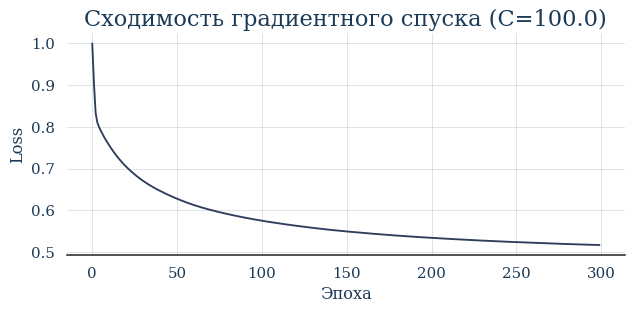

In [11]:
clf = LinearSVM(C=best_C, lr=0.05, n_epochs=300)
clf.fit(F_tr, y_tr, sample_weight=class_weights(y_tr))

plt.figure(figsize=(8, 3.2))
plt.plot(clf.losses)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title(f'Сходимость градиентного спуска (C={best_C})')
plt.grid(alpha=0.3)
plt.show()

## 7. Опорные векторы

Точки с $y_i (w \cdot x_i + b) \leq 1$ — те, что в зазоре или на чужой стороне. Только они держат границу.

Ширина зазора $= 2 / \|w\|$.

In [12]:
margins_tr = y_tr * (F_tr @ clf.w + clf.b)
is_sv = margins_tr <= 1
n_sv = int(is_sv.sum())
margin_width = 2.0 / np.linalg.norm(clf.w)

print(f'Опорных векторов: {n_sv} из {len(y_tr)}  ({100*n_sv/len(y_tr):.1f}%)')
print(f'  из Target:    {int(((y_tr == 1)  & is_sv).sum())} / {(y_tr == 1).sum()}')
print(f'  из NonTarget: {int(((y_tr == -1) & is_sv).sum())} / {(y_tr == -1).sum()}')
print(f'Ширина зазора 2/||w|| = {margin_width:.3f}')

Опорных векторов: 2483 из 4148  (59.9%)
  из Target:    403 / 692
  из NonTarget: 2080 / 3456
Ширина зазора 2/||w|| = 1.290


60% — много. Значит классы сильно перекрываются (что и видно по средним развёрткам).

## 8. Метрики

- **Accuracy** $= \dfrac{TP + TN}{TP + TN + FP + FN}$. Обманчива при дисбалансе.
- **Precision** $= \dfrac{TP}{TP + FP}$. Из названных Target — сколько реально.
- **Recall** $= \dfrac{TP}{TP + FN}$. Из реальных Target — сколько поймали.
- **F1** $= \dfrac{2 \cdot P \cdot R}{P + R}$. Главная при дисбалансе.

In [13]:
pred_te  = clf.predict(F_te)
score_te = clf.decision_function(F_te)

tp = ((pred_te == 1)  & (y_te == 1)).sum()
fp = ((pred_te == 1)  & (y_te == -1)).sum()
fn = ((pred_te == -1) & (y_te == 1)).sum()
tn = ((pred_te == -1) & (y_te == -1)).sum()

acc  = (tp + tn) / (tp + fp + fn + tn)
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

print('Confusion matrix:')
print('                 pred NonTarget   pred Target')
print(f'  true NonTarget     {tn:6d}        {fp:6d}')
print(f'  true Target        {fn:6d}        {tp:6d}')
print()
print(f'Accuracy : {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall   : {rec:.3f}')
print(f'F1       : {f1:.3f}')

Confusion matrix:
                 pred NonTarget   pred Target
  true NonTarget        683           181
  true Target            34           138

Accuracy : 0.792
Precision: 0.433
Recall   : 0.802
F1       : 0.562


## 9. ROC

Скор SVM $= w \cdot x + b$. По умолчанию режем по 0, можно по любому числу. ROC показывает что будет.

- **TPR** $= \dfrac{TP}{TP + FN}$ — поймали из настоящих Target
- **FPR** $= \dfrac{FP}{FP + TN}$ — зря назвали Target из NonTarget

**AUC** = площадь под кривой. $0.5$ — случайный, $1$ — идеальный.

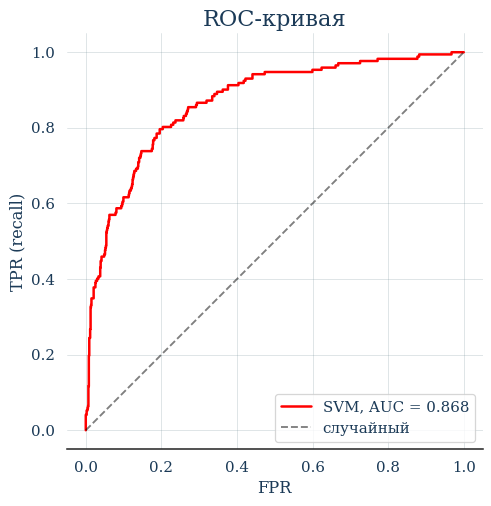

AUC = 0.868


In [14]:
def roc_curve_and_auc(y_true, scores):
    order = np.argsort(-scores)
    y_sorted = y_true[order]

    is_pos = (y_sorted == 1)
    is_neg = ~is_pos

    P = is_pos.sum()
    N = is_neg.sum()

    tpr = np.cumsum(is_pos) / P
    fpr = np.cumsum(is_neg) / N

    tpr = np.concatenate([[0], tpr])
    fpr = np.concatenate([[0], fpr])

    auc = np.trapezoid(tpr, fpr)
    return fpr, tpr, float(auc)


fpr, tpr, auc = roc_curve_and_auc(y_te, score_te)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, color='red', label=f'SVM, AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='случайный')
plt.xlabel('FPR')
plt.ylabel('TPR (recall)')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

print(f'AUC = {auc:.3f}')